# Stock Investment Analysis: TSLA, RKLB, NFLX, PLTR, MUX, QBTS, QUBT, SSL

This notebook helps you compare and analyze eight stocks, grouped as follows:

**Group 1:** TSLA, RKLB, NFLX, PLTR  
**Group 2:** MUX, QBTS, QUBT, SSL

We will analyze and visualize these groups throughout the notebook.

## 1. Set Up the Jupyter Notebook Environment

We will install and import the necessary Python packages for financial data analysis and define our stock groups.

In [26]:
# Install required packages (uncomment if running for the first time)
# !pip install yfinance pandas matplotlib

try:
    import yfinance as yf
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    print("A required package is missing. Please run the pip install command above.")
    raise

# Define stock groups
group1 = ['TSLA', 'NFLX', 'PLTR']
group2 = ['RKLB', 'MUX', 'QBTS', 'QUBT', 'SSL']
all_stocks = group1 + group2

## 2. Investor Ratings

In this section, we will retrieve and display the latest analyst/investor ratings for each stock in both groups.

## 3. Investor or Analyst Advice

This section will display the latest analyst advice or summary for each stock, if available.

## 4. Analyst Target Price

This section will display the latest analyst target price for each stock, if available.

In [27]:
# Retrieve and display analyst target price for each stock
target_prices = {}
for ticker in all_stocks:
    stock = yf.Ticker(ticker)
    try:
        info = stock.info
        target = info.get('targetMeanPrice')
        if target:
            target_prices[ticker] = f"${target:.2f}"
        else:
            target_prices[ticker] = "No target price available."
    except Exception as e:
        target_prices[ticker] = f"Error retrieving target price: {e}"

for ticker in all_stocks:
    print(f"{ticker}: {target_prices[ticker]}")

TSLA: $416.15
NFLX: $113.90
PLTR: $185.25
RKLB: $87.40
MUX: $31.70
QBTS: $36.76
QUBT: $17.40
SSL: $13.00


In [28]:
# Retrieve and display analyst advice/summary for each stock
advice = {}
for ticker in all_stocks:
    stock = yf.Ticker(ticker)
    try:
        info = stock.info
        # Use 'longBusinessSummary' or 'summary' if available
        summary = info.get('longBusinessSummary') or info.get('summary')
        if summary:
            advice[ticker] = summary
        else:
            advice[ticker] = "No analyst advice/summary available."
    except Exception as e:
        advice[ticker] = f"Error retrieving advice: {e}"

for ticker in all_stocks:
    print(f"{ticker}: {advice[ticker][:200]}{'...' if len(advice[ticker]) > 200 else ''}")

TSLA: Tesla, Inc. designs, develops, manufactures, leases, and sells electric vehicles, and energy generation and storage systems in the United States, China, and internationally. The company operates in tw...
NFLX: Netflix, Inc. provides entertainment services worldwide. The company offers television (TV) series, documentaries, feature films, games, and live programming across various genres and languages. It al...
PLTR: Palantir Technologies Inc. builds and deploys software platforms for the intelligence community to assist in counterterrorism investigations and operations in the United States, the United Kingdom, an...
RKLB: Rocket Lab Corporation, a space company, provides launch services and space systems solutions in the United States, Canada, Japan, and internationally. The company operates through launch services and...
MUX: McEwen Inc. engages in the exploration, development, production, and sale of gold and silver deposits in the United States, Canada, Mexico, and Argentina. 

In [29]:
# Fetch basic info and recent price data for all stocks (2 years)
data = {}
for ticker in all_stocks:
    stock = yf.Ticker(ticker)
    hist = stock.history(period='2y')
    data[ticker] = hist['Close']

# Display the latest available closing price for each stock
for ticker in all_stocks:
    if not data[ticker].empty:
        print(f"{ticker}: {data[ticker].iloc[-1]:.2f}")
    else:
        print(f"{ticker}: No data available")

TSLA: 341.11
NFLX: 99.05
PLTR: 141.85
RKLB: 69.10
MUX: 21.34
QBTS: 14.34
QUBT: 6.91
SSL: 12.44


In [30]:
# Retrieve and display analyst/investor ratings for each stock
ratings = {}
for ticker in all_stocks:
    stock = yf.Ticker(ticker)
    try:
        rec = stock.recommendations
        if rec is not None and not rec.empty:
            latest = rec.iloc[-1]
            # Show all available columns for the latest recommendation
            ratings[ticker] = latest.to_dict()
        else:
            ratings[ticker] = "No recent analyst rating found."
    except Exception as e:
        ratings[ticker] = f"Error retrieving rating: {e}"

for ticker in all_stocks:
    print(f"{ticker}: {ratings[ticker]}")

TSLA: {'period': '-3m', 'strongBuy': 4, 'buy': 17, 'hold': 18, 'sell': 6, 'strongSell': 2}
NFLX: {'period': '-3m', 'strongBuy': 9, 'buy': 22, 'hold': 13, 'sell': 1, 'strongSell': 0}
PLTR: {'period': '-2m', 'strongBuy': 1, 'buy': 6, 'hold': 16, 'sell': 2, 'strongSell': 2}
RKLB: {'period': '-3m', 'strongBuy': 2, 'buy': 8, 'hold': 5, 'sell': 0, 'strongSell': 0}
MUX: {'period': '-2m', 'strongBuy': 1, 'buy': 5, 'hold': 0, 'sell': 0, 'strongSell': 0}
QBTS: {'period': '-3m', 'strongBuy': 2, 'buy': 12, 'hold': 0, 'sell': 1, 'strongSell': 0}
QUBT: {'period': '-1m', 'strongBuy': 0, 'buy': 3, 'hold': 2, 'sell': 0, 'strongSell': 0}
SSL: {'period': '-1m', 'strongBuy': 0, 'buy': 0, 'hold': 1, 'sell': 0, 'strongSell': 0}


## 3. Display Output in the Output Pane

Let's visualize the closing prices for each group of stocks over the past year, with axis titles.

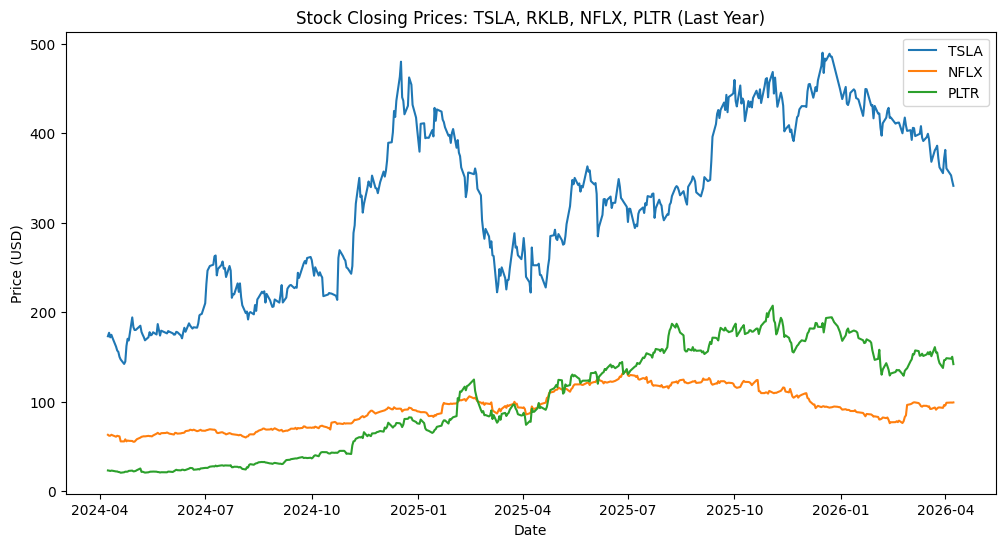

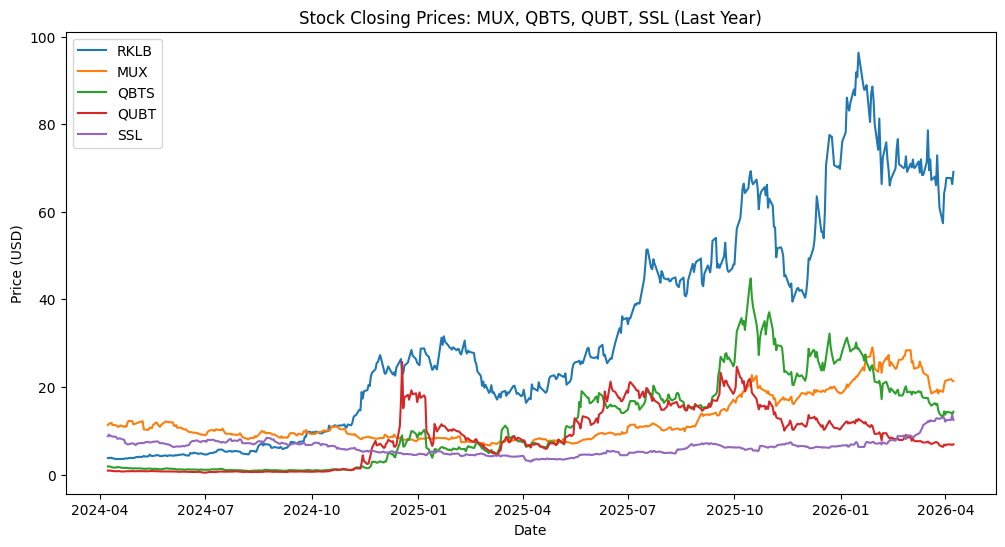

In [31]:
# Plot Group 1: TSLA, RKLB, NFLX, PLTR
plt.figure(figsize=(12,6))
for ticker in group1:
    if not data[ticker].empty:
        plt.plot(data[ticker].index, data[ticker], label=ticker)
plt.title('Stock Closing Prices: TSLA, RKLB, NFLX, PLTR (Last Year)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Plot Group 2: MUX, QBTS, QUBT, SSL
plt.figure(figsize=(12,6))
for ticker in group2:
    if not data[ticker].empty:
        plt.plot(data[ticker].index, data[ticker], label=ticker)
plt.title('Stock Closing Prices: MUX, QBTS, QUBT, SSL (Last Year)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 4. Use the Integrated Terminal

You can open the integrated terminal in VS Code to run shell commands, manage your Python environment, or install packages. For example:

- `pip install yfinance pandas matplotlib`
- `python --version`
- `conda activate <env_name>`

All 8 stocks are grouped and visualized consistently throughout this notebook.

## 5. Write and Run Unit Tests

Let's write a simple unit test to check if our data fetching function works as expected for all 8 stocks.

In [32]:
import unittest

class TestStockData(unittest.TestCase):
    def test_data_fetch(self):
        # Check that data for all stocks is present and has price history
        for ticker in all_stocks:
            self.assertIn(ticker, data)
            self.assertFalse(data[ticker].empty)

unittest.main(argv=[''], exit=False)

.
----------------------------------------------------------------------
Ran 1 test in 0.001s

OK
